# IDRiD — Multiclass (0–4) CNN Ensemble (timm) with AMP, Class Weights, and Temperature Scaling

This notebook trains **three CNN backbones** (EfficientNet-B0, ResNet-50, DenseNet-121) for **multiclass diabetic retinopathy (0–4)** on IDRiD, then **ensembles** their calibrated probabilities.

**Fixes included** (compared to your binary notebook):
- Fully **multiclass** pipeline (CrossEntropy) with **class weights** from the training set
- All missing imports / globals fixed (`CFG`, `DEVICE`, metrics, etc.)
- **Robust CSV parsing** (ignores the *Risk of macular edema* column), **robust image path resolution** (walks the IMG_DIR)
- **AMP** (mixed precision), **early stopping**, **weighted ensemble** by validation Macro-F1
- **Temperature scaling** (scalar) per model on the validation logits
- Rich **metrics**: Accuracy, Macro-F1, Macro ROC-AUC (OvR, if possible), confusion matrix + classification report
- OOM guards: configurable `img_size`, `batch_size`, `accum_steps`

> **Data paths** (as requested):
> - `CSV_PATH = "/kaggle/input/idrid-dataset/idrid_labels.csv"`  
> - `IMG_DIR  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"`


In [1]:
# If needed, install extras. Kaggle generally has timm & albumentations preinstalled.
try:
    import timm  # noqa
except Exception:
    !pip -q install timm
try:
    import albumentations  # noqa
except Exception:
    !pip -q install albumentations==1.4.7

import os, gc, sys, json, math, random, time, glob
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import cv2
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (6, 5)
sns.set(style="whitegrid")


In [2]:
# ======================
# Config & Environment
# ======================
@dataclass
class CFG:
    CSV_PATH: str = "/kaggle/input/idrid-dataset/idrid_labels.csv"
    IMG_DIR: str  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"
    out_dir: str  = "./outputs_idrid_multiclass"
    backbones: tuple = ("efficientnet_b0", "resnet50", "densenet121")
    img_size: int = 384
    batch_size: int = 16
    num_workers: int = 2
    epochs: int = 15
    lr: float = 3e-4
    weight_decay: float = 1e-4
    train_ratio: float = 0.70
    valid_ratio: float = 0.15
    seed: int = 42
    amp: bool = True
    accum_steps: int = 1
    patience: int = 3
    do_calibration: bool = True
    num_classes: int = 5
    tta_hflip: bool = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(CFG.out_dir, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.seed)
print("Device:", DEVICE)


Device: cuda


In [3]:
# ======================
# Data: CSV + Image Index
# ======================
def read_labels(csv_path):
    # Robust read: ignore unknown columns and whitespace in header names
    df = pd.read_csv(csv_path)
    # Normalize columns
    df.columns = [c.strip() for c in df.columns]
    # We only need id_code and diagnosis
    if "id_code" not in df.columns or "diagnosis" not in df.columns:
        raise ValueError("CSV must contain 'id_code' and 'diagnosis' columns.")
    df = df[["id_code", "diagnosis"]].copy()
    # Ensure int labels [0..4]
    df["diagnosis"] = pd.to_numeric(df["diagnosis"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["id_code", "diagnosis"]).reset_index(drop=True)
    df["diagnosis"] = df["diagnosis"].astype(int)
    return df

def build_image_lookup(root_dir):
    """
    Build a dict mapping basename without extension (e.g., 'IDRiD_001') to absolute path.
    Recursively walks the given root folder.
    """
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"IMG_DIR not found: {root_dir}")
    lookup = {}
    exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".JPG", ".PNG", ".JPEG", ".TIF", ".TIFF", ".BMP"}
    for p in root.rglob("*"):
        if p.suffix in exts and p.is_file():
            lookup[p.stem] = str(p.resolve())
    return lookup

labels_df = read_labels(CFG.CSV_PATH)
print("CSV loaded:", labels_df.shape, labels_df.head(3))
img_lookup = build_image_lookup(CFG.IMG_DIR)
print("Indexed images:", len(img_lookup))

def add_image_paths(df, lookup):
    paths = []
    missing = 0
    for _, row in df.iterrows():
        key = str(row["id_code"]).strip()
        path = lookup.get(key, None)
        if path is None:
            missing += 1
        paths.append(path)
    df = df.copy()
    df["image_path"] = paths
    if missing > 0:
        print(f"[WARN] {missing} images were not found by id_code. They will be dropped.")
    df = df.dropna(subset=["image_path"]).reset_index(drop=True)
    return df

labels_df = add_image_paths(labels_df, img_lookup)
print("After matching paths:", labels_df.shape)
labels_df.head()


CSV loaded: (455, 2)      id_code  diagnosis
0  IDRiD_001          3
1  IDRiD_002          3
2  IDRiD_003          2
Indexed images: 455
After matching paths: (455, 3)


,id_code,diagnosis,image_path
0,IDRiD_001,3,/kaggle/input/idrid-dataset/Imagenes/Imagenes/...
1,IDRiD_002,3,/kaggle/input/idrid-dataset/Imagenes/Imagenes/...
2,IDRiD_003,2,/kaggle/input/idrid-dataset/Imagenes/Imagenes/...
3,IDRiD_004,3,/kaggle/input/idrid-dataset/Imagenes/Imagenes/...
4,IDRiD_005,4,/kaggle/input/idrid-dataset/Imagenes/Imagenes/...


In [4]:
# ======================
# Transforms & Dataset
# ======================
def crop_black_borders(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(gray > 10)
    if len(xs) == 0:
        return img_bgr
    x1, x2, y1, y2 = xs.min(), xs.max(), ys.min(), ys.max()
    return img_bgr[y1:y2+1, x1:x2+1]

def load_fundus_image(path, target_size):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found or unreadable: {path}")
    img = crop_black_borders(img)
    # mild shade correction / unsharp
    blur = cv2.medianBlur(img, 31)
    img = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA)
    return img

train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.1, rotate_limit=15, p=0.7, border_mode=cv2.BORDER_REFLECT101),
    A.RandomBrightnessContrast(0.1, 0.1, p=0.7),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.3),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(),
    ToTensorV2(),
])
valid_tfms = A.Compose([A.Normalize(), ToTensorV2()])

class IDRiDDataset(Dataset):
    def __init__(self, df, transforms=None, img_size=384):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.img_size = img_size
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_fundus_image(row.image_path, self.img_size)
        if self.transforms:
            img = self.transforms(image=img)["image"]
        label = int(row.diagnosis)
        label = torch.tensor(label, dtype=torch.long)
        return img, label


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
# ======================
# Train/Valid/Test Split (Stratified)
# ======================
# 70/15/15 split by diagnosis (stratified). Avoid leakage if multiple images per patient (IDRiD uses unique ids per row)
train_df, temp_df = train_test_split(labels_df, test_size=1-CFG.train_ratio, stratify=labels_df["diagnosis"], random_state=CFG.seed)
valid_ratio_rel = CFG.valid_ratio / (1-CFG.train_ratio)
valid_df, test_df = train_test_split(temp_df, test_size=1-valid_ratio_rel, stratify=temp_df["diagnosis"], random_state=CFG.seed)

print("Splits:")
for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    print(f"{name:>5}: {df.shape[0]}  class counts:", df["diagnosis"].value_counts().sort_index().to_dict())


Splits:
train: 318  class counts: {0: 90, 1: 15, 2: 109, 3: 59, 4: 45}
valid: 68  class counts: {0: 19, 1: 4, 2: 23, 3: 12, 4: 10}
 test: 69  class counts: {0: 20, 1: 3, 2: 24, 3: 13, 4: 9}


In [6]:
# ======================
# Dataloaders
# ======================
train_ds = IDRiDDataset(train_df, transforms=train_tfms, img_size=CFG.img_size)
valid_ds = IDRiDDataset(valid_df, transforms=valid_tfms, img_size=CFG.img_size)
test_ds  = IDRiDDataset(test_df,  transforms=valid_tfms, img_size=CFG.img_size)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,  num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True)
valid_loader = DataLoader(valid_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True)

len(train_ds), len(valid_ds), len(test_ds)


(318, 68, 69)

In [7]:
# ======================
# Utilities: Metrics, Eval, Temperature Scaling
# ======================
def compute_class_weights(y):
    y = np.asarray(y, dtype=int)
    counts = np.bincount(y, minlength=CFG.num_classes).astype(float)
    counts[counts == 0] = 1.0
    inv = 1.0 / counts
    weights = inv / inv.sum() * CFG.num_classes  # normalized inverse frequency
    return weights

def softmax_np(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)

def evaluate_model(model, loader, loss_fn=None, temperature=None):
    model.eval()
    all_logits, all_labels = [], []
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=CFG.amp):
                logits = model(x)
            if temperature is not None:
                logits = logits / temperature
            if loss_fn is not None:
                loss = loss_fn(logits, y)
                total_loss += loss.item() * x.size(0)
                total_n += x.size(0)
            all_logits.append(logits.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())
    logits = np.vstack(all_logits) if all_logits else np.zeros((0, CFG.num_classes))
    labels = np.concatenate(all_labels) if all_labels else np.zeros((0,), dtype=int)
    probs = softmax_np(logits) if logits.size else np.zeros((0, CFG.num_classes))
    preds = probs.argmax(axis=1) if probs.size else np.zeros((0,), dtype=int)

    metrics = {}
    if total_n > 0:
        metrics["loss"] = total_loss / total_n
    metrics["accuracy"] = float(accuracy_score(labels, preds)) if labels.size else 0.0
    metrics["macro_f1"] = float(f1_score(labels, preds, average="macro")) if labels.size else 0.0

    # Macro ROC-AUC OvR (may fail if some classes missing in labels)
    try:
        auc_macro = roc_auc_score(labels, probs, multi_class="ovr", average="macro", labels=np.arange(CFG.num_classes))
        metrics["macro_roc_auc_ovr"] = float(auc_macro)
    except Exception as e:
        metrics["macro_roc_auc_ovr"] = float("nan")

    return logits, probs, labels, preds, metrics

class TemperatureScaler(nn.Module):
    """
    Scalar temperature scaling for multiclass logits.
    """
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))  # T = exp(log_T), starts at 1.0
    def forward(self, logits):
        T = torch.exp(self.log_T)
        return logits / T
    def fit(self, logits, labels, max_iter=200, lr=0.01, verbose=False):
        """
        logits: torch.tensor [N,C], labels: torch.tensor [N]
        """
        self.train()
        opt = torch.optim.LBFGS([self.log_T], lr=0.5, max_iter=50)
        nll = nn.CrossEntropyLoss()
        logits = logits.detach()
        labels = labels.detach()
        def closure():
            opt.zero_grad(set_to_none=True)
            loss = nll(self.forward(logits), labels)
            loss.backward()
            return loss
        try:
            opt.step(closure)
        except Exception:
            # fallback to Adam
            opt = torch.optim.Adam([self.log_T], lr=lr)
            for _ in range(max_iter):
                opt.zero_grad(set_to_none=True)
                loss = nll(self.forward(logits), labels)
                loss.backward()
                opt.step()
        if verbose:
            print("Fitted temperature T =", float(torch.exp(self.log_T).detach().cpu().numpy()))
    def temperature(self):
        with torch.no_grad():
            return float(torch.exp(self.log_T).cpu().numpy())


In [8]:
# ======================
# Training: one backbone
# ======================
def train_one_backbone(backbone, train_loader, valid_loader, y_train):
    print(f"\n==== Training {backbone} ====")
    model = timm.create_model(backbone, pretrained=True, num_classes=CFG.num_classes)
    model.to(DEVICE)

    class_weights = compute_class_weights(y_train)
    cw_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=cw_tensor).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=CFG.amp)

    best_metric = -1.0
    best_path = os.path.join(CFG.out_dir, f"{backbone}.pt")
    patience = CFG.patience
    bad_epochs = 0

    for epoch in range(1, CFG.epochs + 1):
        model.train()
        epoch_loss = 0.0
        seen = 0
        optimizer.zero_grad(set_to_none=True)
        for i, (x, y) in enumerate(train_loader, 1):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=CFG.amp):
                logits = model(x)
                loss = loss_fn(logits, y) / CFG.accum_steps
            scaler.scale(loss).backward()
            if i % CFG.accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            epoch_loss += loss.item() * x.size(0) * CFG.accum_steps
            seen += x.size(0)
        scheduler.step()

        # Validation
        _, _, yv, pv, vmetrics = evaluate_model(model, valid_loader, loss_fn=None, temperature=None)
        print(f"Epoch {epoch:02d} | train_loss={epoch_loss/seen:.4f} | val_acc={vmetrics['accuracy']:.4f} | val_macroF1={vmetrics['macro_f1']:.4f} | val_AUC(ovr)={vmetrics['macro_roc_auc_ovr']}")

        if vmetrics["macro_f1"] > best_metric + 1e-6:
            best_metric = vmetrics["macro_f1"]
            bad_epochs = 0
            torch.save(model.state_dict(), best_path)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch}. Best val Macro-F1: {best_metric:.4f}")
                break

    # Load best
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    # Temperature scaling on validation set (optional)
    T_value = 1.0
    if CFG.do_calibration:
        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for x, y in valid_loader:
                x = x.to(DEVICE, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=CFG.amp):
                    logits = model(x)
                all_logits.append(logits.detach().cpu())
                all_labels.append(y.detach().cpu())
        if all_logits:
            val_logits = torch.cat(all_logits, dim=0)
            val_labels = torch.cat(all_labels, dim=0).long()
            scaler_T = TemperatureScaler().to("cpu")
            scaler_T.fit(val_logits, val_labels, verbose=False)
            T_value = scaler_T.temperature()
            print(f"Calibrated temperature (scalar) for {backbone}: T = {T_value:.4f}")

    return model, best_path, T_value, best_metric


In [9]:
# ======================
# Train all backbones
# ======================
y_train_np = train_df["diagnosis"].values
trained = []  # list of dicts with model, path, T, val_metric

for bb in CFG.backbones:
    model, path, T, valF1 = train_one_backbone(bb, train_loader, valid_loader, y_train_np)
    trained.append({"backbone": bb, "path": path, "T": T, "val_macro_f1": valF1})
    # Free up some memory
    gc.collect()
    torch.cuda.empty_cache()

print("\nSummary of trained models:")
for t in trained:
    print(t)
with open(os.path.join(CFG.out_dir, "models_summary.json"), "w") as f:
    json.dump(trained, f, indent=2)



==== Training efficientnet_b0 ====


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipykernel_36/2886745874.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CFG.amp)
/tmp/ipykernel_36/2886745874.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):


Epoch 01 | train_loss=2.2357 | val_acc=0.5588 | val_macroF1=0.4813 | val_AUC(ovr)=nan


/tmp/ipykernel_36/2886745874.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):


...

Epoch 05 | train_loss=0.7099 | val_acc=0.7059 | val_macroF1=0.6435 | val_AUC(ovr)=nan


/tmp/ipykernel_36/2886745874.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):


Epoch 06 | train_loss=0.6726 | val_acc=0.6912 | val_macroF1=0.6256 | val_AUC(ovr)=nan
Early stopping at epoch 6. Best val Macro-F1: 0.6831


/tmp/ipykernel_36/2886745874.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(torch.exp(self.log_T).cpu().numpy())


Calibrated temperature (scalar) for densenet121: T = 0.6198

Summary of trained models:
{'backbone': 'efficientnet_b0', 'path': './outputs_idrid_multiclass/efficientnet_b0.pt', 'T': 2.047255039215088, 'val_macro_f1': 0.7730446024563671}
{'backbone': 'resnet50', 'path': './outputs_idrid_multiclass/resnet50.pt', 'T': 0.7246621251106262, 'val_macro_f1': 0.641294414512719}
{'backbone': 'densenet121', 'path': './outputs_idrid_multiclass/densenet121.pt', 'T': 0.6198280453681946, 'val_macro_f1': 0.6830506409183086}


/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):


Ensemble weights (by val Macro-F1): {'efficientnet_b0': 0.3685746230078295, 'resnet50': 0.30575835639366394, 'densenet121': 0.32566702059850644}


/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):


[Ensemble] VALID | acc=0.7500 | macroF1=0.6993 | AUC(ovr)=nan


/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):
/tmp/ipykernel_36/2252029313.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.amp):


[Ensemble] TEST  | acc=0.6522 | macroF1=0.5212 | AUC(ovr)=nan

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.7391    0.8500    0.7907        20
           1     0.0000    0.0000    0.0000         3
           2     0.6800    0.7083    0.6939        24
           3     0.5556    0.3846    0.4545        13
           4     0.6667    0.6667    0.6667         9

    accuracy                         0.6522        69
   macro avg     0.5283    0.5219    0.5212        69
weighted avg     0.6424    0.6522    0.6431        69



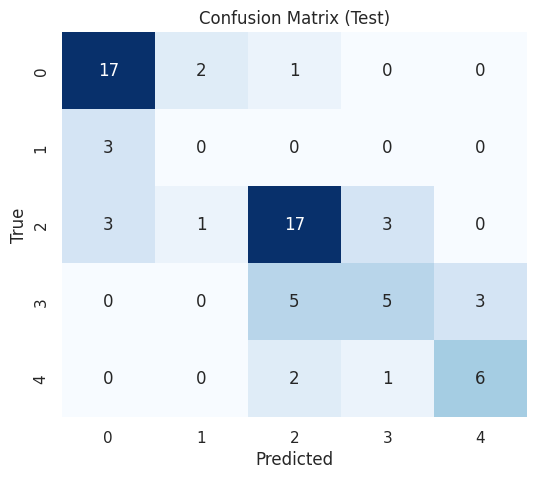


Saved:
 - ./outputs_idrid_multiclass/test_predictions.csv
 - ./outputs_idrid_multiclass/results_summary.json
 - ./outputs_idrid_multiclass/models_summary.json


In [10]:
# ======================
# Evaluation & Ensemble
# ======================
def load_model(backbone, path):
    m = timm.create_model(backbone, pretrained=False, num_classes=CFG.num_classes).to(DEVICE)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval()
    return m

# Load all best models
models = []
for t in trained:
    m = load_model(t["backbone"], t["path"])
    models.append({"name": t["backbone"], "model": m, "T": t["T"], "val_macro_f1": t["val_macro_f1"]})

# Validation metrics per model (with calibration)
val_results = []
for item in models:
    T = item["T"]
    _, probs, y_true, y_pred, metrics = evaluate_model(item["model"], valid_loader, loss_fn=None, temperature=T)
    metrics["backbone"] = item["name"]
    val_results.append(metrics)
pd.DataFrame(val_results)

# Compute ensemble weights from validation macro_f1 (avoid zeros)
weights = np.array([max(1e-6, it["val_macro_f1"]) for it in models], dtype=float)
weights = weights / weights.sum()
print("Ensemble weights (by val Macro-F1):", dict(zip([m["name"] for m in models], weights)))

def predict_proba_ensemble(loader, models, weights):
    all_probs = []
    for i, item in enumerate(models):
        T = item["T"]
        _, probs, _, _, _ = evaluate_model(item["model"], loader, loss_fn=None, temperature=T)
        all_probs.append(probs)
    # weighted average
    ens = np.zeros_like(all_probs[0])
    for w, p in zip(weights, all_probs):
        ens += w * p
    return ens

# Evaluate on VALID (ensemble) for a sanity check
ens_valid_probs = predict_proba_ensemble(valid_loader, models, weights)
y_valid = valid_df["diagnosis"].values
y_valid_pred = ens_valid_probs.argmax(axis=1)
valid_acc = accuracy_score(y_valid, y_valid_pred)
valid_f1 = f1_score(y_valid, y_valid_pred, average="macro")
try:
    valid_auc = roc_auc_score(y_valid, ens_valid_probs, multi_class="ovr", average="macro", labels=np.arange(CFG.num_classes))
except Exception:
    valid_auc = float("nan")
print(f"[Ensemble] VALID | acc={valid_acc:.4f} | macroF1={valid_f1:.4f} | AUC(ovr)={valid_auc}")

# Evaluate on TEST
ens_test_probs = predict_proba_ensemble(test_loader, models, weights)
y_test = test_df["diagnosis"].values
y_test_pred = ens_test_probs.argmax(axis=1)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average="macro")
try:
    test_auc = roc_auc_score(y_test, ens_test_probs, multi_class="ovr", average="macro", labels=np.arange(CFG.num_classes))
except Exception:
    test_auc = float("nan")
print(f"[Ensemble] TEST  | acc={test_acc:.4f} | macroF1={test_f1:.4f} | AUC(ovr)={test_auc}")

# Classification report & confusion matrix
print("\nClassification report (TEST):")
print(classification_report(y_test, y_test_pred, digits=4))

cm = confusion_matrix(y_test, y_test_pred, labels=list(range(CFG.num_classes)))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=list(range(CFG.num_classes)),
            yticklabels=list(range(CFG.num_classes)))
ax.set_title("Confusion Matrix (Test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.show()

# Save per-image predictions
out_csv = os.path.join(CFG.out_dir, "test_predictions.csv")
pred_df = test_df.copy()
for c in range(CFG.num_classes):
    pred_df[f"prob_{c}"] = ens_test_probs[:, c]
pred_df["pred"] = y_test_pred
pred_df.to_csv(out_csv, index=False)

# Save summary metrics
summary = {
    "valid": {"accuracy": float(valid_acc), "macro_f1": float(valid_f1), "macro_roc_auc_ovr": float(valid_auc)},
    "test":  {"accuracy": float(test_acc),  "macro_f1": float(test_f1),  "macro_roc_auc_ovr": float(test_auc)},
    "weights": dict(zip([m["name"] for m in models], [float(w) for w in weights]))
}
with open(os.path.join(CFG.out_dir, "results_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:")
print(" -", out_csv)
print(" -", os.path.join(CFG.out_dir, "results_summary.json"))
print(" -", os.path.join(CFG.out_dir, "models_summary.json"))


In [11]:
# ======================
# Optional: Simple TTA helpers (horizontal flip at inference)
# ======================
def evaluate_model_tta_hflip(model, loader, temperature=None):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            x_flip = torch.flip(x, dims=[3])
            with torch.cuda.amp.autocast(enabled=CFG.amp):
                logits = model(x)
                logits_f = model(x_flip)
                if temperature is not None:
                    logits = logits / temperature
                    logits_f = logits_f / temperature
                probs = F.softmax(logits, dim=1).detach().cpu().numpy()
                probs_f = F.softmax(logits_f, dim=1).detach().cpu().numpy()
                probs = 0.5 * (probs + probs_f)
            all_probs.append(probs)
            all_labels.append(y.numpy())
    probs = np.vstack(all_probs)
    labels = np.concatenate(all_labels)
    preds = probs.argmax(axis=1)
    return probs, labels, preds
